In [1]:
!pip install dask[dataframe] pyarrow psutil matplotlib pandas numpy

In [2]:
import pandas as pd
import dask.dataframe as dd
import pyarrow as pa
import pyarrow.csv as pa_csv
import pyarrow.compute as pc

import time
import tracemalloc
import psutil
import os
import gc
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [3]:
file_path = "cleaned_data.csv"

df_check = pd.read_csv(file_path)
print(df_check.shape)
print(df_check.columns.tolist())
df_check.head()

(147582, 13)
['product_id', 'sku', 'title', 'author', 'publisher', 'current_price', 'compare_price', 'discount_pct', 'grams', 'tags', 'image_url', 'created_at', 'description']


,product_id,sku,title,author,publisher,current_price,compare_price,discount_pct,grams,tags,image_url,created_at,description
0,6978035122382,9780751547238,Visions,Kelley Armstrong,Sphere,17.9,62.90,71.5,355,"[2022], BXOS, F CTM, Fiction, Kelley Armstrong...",https://cdn.shopify.com/s/files/1/0601/0883/29...,2022-04-01T10:46:08+0800,"Olivia Jones is smart, capable, loyal...and th..."
1,6978035318990,9780751548174,The Bone Bed,Patricia Cornwell,Sphere,17.9,43.95,59.3,360,"[2022], BXOS, F CTM, Fiction, Paperback, Patri...",https://cdn.shopify.com/s/files/1/0601/0883/29...,2022-04-01T10:46:08+0800,A woman has vanished while digging a dinosaur ...
2,6978035417294,9781447205180,Jasmine Skies,Sita Brahmachari,MacMillan Children's Books,12.9,32.95,60.8,340,"[2022], BXOS, F YA, Fiction, Paperback, RM 10 ...",https://cdn.shopify.com/s/files/1/0601/0883/29...,2022-04-01T10:46:09+0800,Mira Levenson is bursting with excitement as s...
3,6978034794702,9780099461050,The Old Devils,Kingsley Amis,Vintage Publishing,17.9,59.94,70.1,310,"[2022], BXOS, F LIT, Fiction, Kingsley Amis, P...",https://cdn.shopify.com/s/files/1/0601/0883/29...,2022-04-01T10:46:07+0800,"Malcolm, Peter and Charlie and their Soave-sod..."
4,6978035515598,9781473223288,PHILIP K. DICK'S ELECTRIC DREAMS: VOLUME 1,Philip K. Dick,Gollancz,17.9,53.94,66.8,230,"[2022], BXOS, F SFF, Fiction, Paperback, Phili...",https://cdn.shopify.com/s/files/1/0601/0883/29...,2022-04-01T10:46:09+0800,"Based on the stories contained in this volume,..."


In [4]:
def flush_memory():
    gc.collect()
    time.sleep(1.0)


def benchmark(operation_name, library_name, func, total_rows, runs=3):
    """
    Run func `runs` times with memory flushing between runs.
    Returns a list of dicts: one row per run (1..runs) plus one
    trailing 'average' row. Memory tracked via tracemalloc (always >= 0).
    CPU is captured both before (initial) and after (final) the operation.
    """
    records = []
    exec_times, cpu_initials, cpu_finals, mems = [], [], [], []

    for run_idx in range(1, runs + 1):
        flush_memory()

        # Clean pre-operation CPU reading (after the 1-second sleep in flush_memory)
        cpu_initial = psutil.cpu_percent(interval=None)

        tracemalloc.start()
        start = time.perf_counter()
        result = func()
        end = time.perf_counter()
        _, peak = tracemalloc.get_traced_memory()  # peak bytes during call
        tracemalloc.stop()

        cpu_final = psutil.cpu_percent(interval=1)  # post-operation reading
        t = end - start
        mem = peak / (1024 * 1024)  # always >= 0
        tput = total_rows / t if t > 0 else 0

        records.append({
            "operation": operation_name,
            "library": library_name,
            "run": run_idx,
            "execution_time_sec": round(t, 6),
            "cpu_initial_percent": round(cpu_initial, 2),
            "cpu_final_percent": round(cpu_final, 2),
            "memory_used_mb": round(mem, 3),
            "throughput_rows_per_sec": round(tput, 0),
        })
        exec_times.append(t)
        cpu_initials.append(cpu_initial)
        cpu_finals.append(cpu_final)
        mems.append(mem)

        del result
        flush_memory()

    avg_t = float(np.mean(exec_times))
    records.append({
        "operation": operation_name,
        "library": library_name,
        "run": "average",
        "execution_time_sec": round(avg_t, 6),
        "cpu_initial_percent": round(float(np.mean(cpu_initials)), 2),
        "cpu_final_percent": round(float(np.mean(cpu_finals)), 2),
        "memory_used_mb": round(float(np.mean(mems)), 3),
        "throughput_rows_per_sec": round(total_rows / avg_t if avg_t > 0 else 0, 0),
    })
    return records

In [5]:
total_rows = len(pd.read_csv(file_path))
print("Total rows:", total_rows)

Total rows: 147582


## Pandas Benchmarks

In [6]:
results = []

# 1. Load CSV
results.extend(benchmark(
    "Load CSV", "Pandas",
    lambda: pd.read_csv(file_path),
    total_rows
))

pdf = pd.read_csv(file_path)
flush_memory()

# 2. Filter high-discount books
results.extend(benchmark(
    "Filter High Discount Books", "Pandas",
    lambda: pdf[(pdf["discount_pct"] > 70) & (pdf["current_price"] < 20)],
    total_rows
))

# 3. GroupBy publisher aggregation
results.extend(benchmark(
    "GroupBy Publisher Aggregation", "Pandas",
    lambda: pdf.groupby("publisher").agg({
        "current_price": "mean",
        "discount_pct": "mean",
        "title": "count"
    }),
    total_rows
))

# 4. String extract price tier
results.extend(benchmark(
    "String Extract Price Tier", "Pandas",
    lambda: pdf["tags"].astype(str).str.extract(r'(RM[\d\s\-\.]+)'),
    total_rows
))

# 5. Derived column calculation
results.extend(benchmark(
    "Calculate Savings", "Pandas",
    lambda: pdf.assign(
        savings_rm=pdf["compare_price"] - pdf["current_price"],
        savings_pct_check=(
            (pdf["compare_price"] - pdf["current_price"]) / pdf["compare_price"] * 100
        ).round(1)
    ),
    total_rows
))

# 6. Sort by discount and price
results.extend(benchmark(
    "Sort by Discount and Price", "Pandas",
    lambda: pdf.sort_values(["discount_pct", "current_price"], ascending=[False, True]),
    total_rows
))

# 7. Top authors by average discount
results.extend(benchmark(
    "Top Authors by Average Discount", "Pandas",
    lambda: pdf.groupby("author")["discount_pct"].mean().sort_values(ascending=False).head(20),
    total_rows
))

# Save performance_before.csv — Pandas only, wide format
def build_wide_csv(df, libraries):
    METRIC_MAP = [
        ("execution_time_sec",      "Total Processing Time (s)"),
        ("cpu_initial_percent",     "Initial CPU Usage (%)"),
        ("cpu_final_percent",       "Final CPU Usage (%)"),
        ("memory_used_mb",          "Memory Usage (MB)"),
        ("throughput_rows_per_sec", "Throughput (rows/sec)"),
    ]
    RUN_LABELS = {1: "1st Run", 2: "2nd Run", 3: "3rd Run", "average": "Average"}
    RUNS = [1, 2, 3, "average"]

    n_cols = len(libraries) * len(RUNS) + 1
    all_rows = []

    for i, op in enumerate(df["operation"].unique(), 1):
        op_df = df[df["operation"] == op]

        # Section header row
        all_rows.append([f"{i}. {op}"] + [""] * (n_cols - 1))

        # Library name row (spans 4 columns each)
        lib_header = [""]
        for lib in libraries:
            lib_header += [lib] + [""] * (len(RUNS) - 1)
        all_rows.append(lib_header)

        # Run label row
        run_header = ["Performance Metrics"]
        for lib in libraries:
            for run in RUNS:
                run_header.append(RUN_LABELS[run])
        all_rows.append(run_header)

        # One data row per metric
        for metric_key, metric_label in METRIC_MAP:
            row = [metric_label]
            for lib in libraries:
                for run in RUNS:
                    mask = (op_df["library"] == lib) & (op_df["run"] == run)
                    vals = op_df.loc[mask, metric_key].values
                    row.append(round(float(vals[0]), 4) if len(vals) > 0 else "")
            all_rows.append(row)

        all_rows.append([""] * n_cols)  # blank separator between operations

    return pd.DataFrame(all_rows)


build_wide_csv(
    pd.DataFrame([r for r in results if r["library"] == "Pandas"]),
    ["Pandas"]
).to_csv("performance_before.csv", index=False, header=False)
print("Saved performance_before.csv")

pd.DataFrame([r for r in results if r["library"] == "Pandas"])

Saved performance_before.csv


,operation,library,run,execution_time_sec,cpu_initial_percent,cpu_final_percent,memory_used_mb,throughput_rows_per_sec
0,Load CSV,Pandas,1,2.723686,30.80,9.70,231.794,54185.0
1,Load CSV,Pandas,2,2.595169,6.80,16.20,231.794,56868.0
2,Load CSV,Pandas,3,2.635969,19.20,5.80,231.794,55988.0
3,Load CSV,Pandas,average,2.651608,18.93,10.57,231.794,55658.0
4,Filter High Discount Books,Pandas,1,0.035578,11.10,7.40,3.249,4148125.0
5,Filter High Discount Books,Pandas,2,0.026331,12.70,9.50,3.239,5604983.0
6,Filter High Discount Books,Pandas,3,0.024162,9.60,5.40,3.239,6108071.0
7,Filter High Discount Books,Pandas,average,0.028690,11.13,7.43,3.242,5144004.0
8,GroupBy Publisher Aggregation,Pandas,1,0.018523,10.60,4.10,2.418,7967457.0
9,GroupBy Publisher Aggregation,Pandas,2,0.017536,6.70,6.60,2.417,8416136.0


## Dask Benchmarks

In [7]:
# 1. Load CSV
results.extend(benchmark(
    "Load CSV", "Dask",
    lambda: dd.read_csv(file_path, dtype={"sku": "object"}).compute(),
    total_rows
))

ddf = dd.read_csv(file_path, dtype={"sku": "object"})
flush_memory()

# 2. Filter high-discount books
results.extend(benchmark(
    "Filter High Discount Books", "Dask",
    lambda: ddf[(ddf["discount_pct"] > 70) & (ddf["current_price"] < 20)].compute(),
    total_rows
))

# 3. GroupBy publisher aggregation
results.extend(benchmark(
    "GroupBy Publisher Aggregation", "Dask",
    lambda: ddf.groupby("publisher").agg({
        "current_price": "mean",
        "discount_pct": "mean",
        "title": "count"
    }).compute(),
    total_rows
))

# 4. String extract price tier
results.extend(benchmark(
    "String Extract Price Tier", "Dask",
    lambda: ddf["tags"].astype(str).str.extract(r'(RM[\d\s\-\.]+)').compute(),
    total_rows
))

# 5. Derived column calculation
results.extend(benchmark(
    "Calculate Savings", "Dask",
    lambda: ddf.assign(
        savings_rm=ddf["compare_price"] - ddf["current_price"],
        savings_pct_check=(
            (ddf["compare_price"] - ddf["current_price"]) / ddf["compare_price"] * 100
        ).round(1)
    ).compute(),
    total_rows
))

# 6. Sort by discount and price
results.extend(benchmark(
    "Sort by Discount and Price", "Dask",
    lambda: ddf.sort_values(["discount_pct", "current_price"], ascending=[False, True]).compute(),
    total_rows
))

# 7. Top authors by average discount
results.extend(benchmark(
    "Top Authors by Average Discount", "Dask",
    lambda: ddf.groupby("author")["discount_pct"].mean().compute().sort_values(ascending=False).head(20),
    total_rows
))

print("Dask benchmarks complete.")

Dask benchmarks complete.


## PyArrow Benchmarks

In [8]:
# 1. Load CSV
results.extend(benchmark(
    "Load CSV", "PyArrow",
    lambda: pa_csv.read_csv(file_path),
    total_rows
))

pa_table = pa_csv.read_csv(file_path)
flush_memory()

# 2. Filter high-discount books
results.extend(benchmark(
    "Filter High Discount Books", "PyArrow",
    lambda: pa_table.filter(
        pc.and_(
            pc.greater(pa_table.column("discount_pct"), 70),
            pc.less(pa_table.column("current_price"), 20)
        )
    ),
    total_rows
))

# 3. GroupBy publisher aggregation
results.extend(benchmark(
    "GroupBy Publisher Aggregation", "PyArrow",
    lambda: pa_table.group_by("publisher").aggregate([
        ("current_price", "mean"),
        ("discount_pct", "mean"),
        ("title", "count"),
    ]),
    total_rows
))

# 4. String extract price tier (named capture group required by PyArrow)
results.extend(benchmark(
    "String Extract Price Tier", "PyArrow",
    lambda: pc.extract_regex(
        pc.cast(pa_table.column("tags"), pa.string()),
        pattern=r'(?P<price_tier>RM[\d\s\-\.]+)'
    ),
    total_rows
))

# 5. Derived column calculation
def _pyarrow_savings():
    savings_rm = pc.subtract(pa_table.column("compare_price"), pa_table.column("current_price"))
    savings_pct = pc.round(
        pc.multiply(
            pc.divide(savings_rm, pa_table.column("compare_price")),
            100
        ),
        1
    )
    return (
        pa_table
        .append_column("savings_rm", savings_rm)
        .append_column("savings_pct_check", savings_pct)
    )

results.extend(benchmark("Calculate Savings", "PyArrow", _pyarrow_savings, total_rows))

# 6. Sort by discount and price
results.extend(benchmark(
    "Sort by Discount and Price", "PyArrow",
    lambda: pa_table.take(
        pc.sort_indices(
            pa_table,
            sort_keys=[("discount_pct", "descending"), ("current_price", "ascending")]
        )
    ),
    total_rows
))

# 7. Top authors by average discount
def _pyarrow_top_authors():
    grp = pa_table.group_by("author").aggregate([("discount_pct", "mean")])
    idx = pc.sort_indices(grp, sort_keys=[("discount_pct_mean", "descending")])
    return grp.take(idx[:20])

results.extend(benchmark("Top Authors by Average Discount", "PyArrow", _pyarrow_top_authors, total_rows))

print("PyArrow benchmarks complete.")

PyArrow benchmarks complete.


## Results Summary

In [9]:
results_df = pd.DataFrame(results)

# Save performance_after.csv — all three libraries, wide format
build_wide_csv(results_df, ["Pandas", "Dask", "PyArrow"]).to_csv(
    "performance_after.csv", index=False, header=False
)
print("Saved performance_after.csv")

results_df

Saved performance_after.csv


,operation,library,run,execution_time_sec,cpu_initial_percent,cpu_final_percent,memory_used_mb,throughput_rows_per_sec
0,Load CSV,Pandas,1,2.723686,30.80,9.70,231.794,54185.0
1,Load CSV,Pandas,2,2.595169,6.80,16.20,231.794,56868.0
2,Load CSV,Pandas,3,2.635969,19.20,5.80,231.794,55988.0
3,Load CSV,Pandas,average,2.651608,18.93,10.57,231.794,55658.0
4,Filter High Discount Books,Pandas,1,0.035578,11.10,7.40,3.249,4148125.0
...,...,...,...,...,...,...,...,...
79,Sort by Discount and Price,PyArrow,average,0.146477,8.30,8.43,0.001,1007547.0
80,Top Authors by Average Discount,PyArrow,1,0.032232,13.50,7.50,0.002,4578742.0
81,Top Authors by Average Discount,PyArrow,2,0.016600,7.80,11.00,0.002,8890696.0
82,Top Authors by Average Discount,PyArrow,3,0.016085,5.40,7.00,0.002,9175246.0


## Charts: Per-Operation Comparison (Pandas vs Dask vs PyArrow)

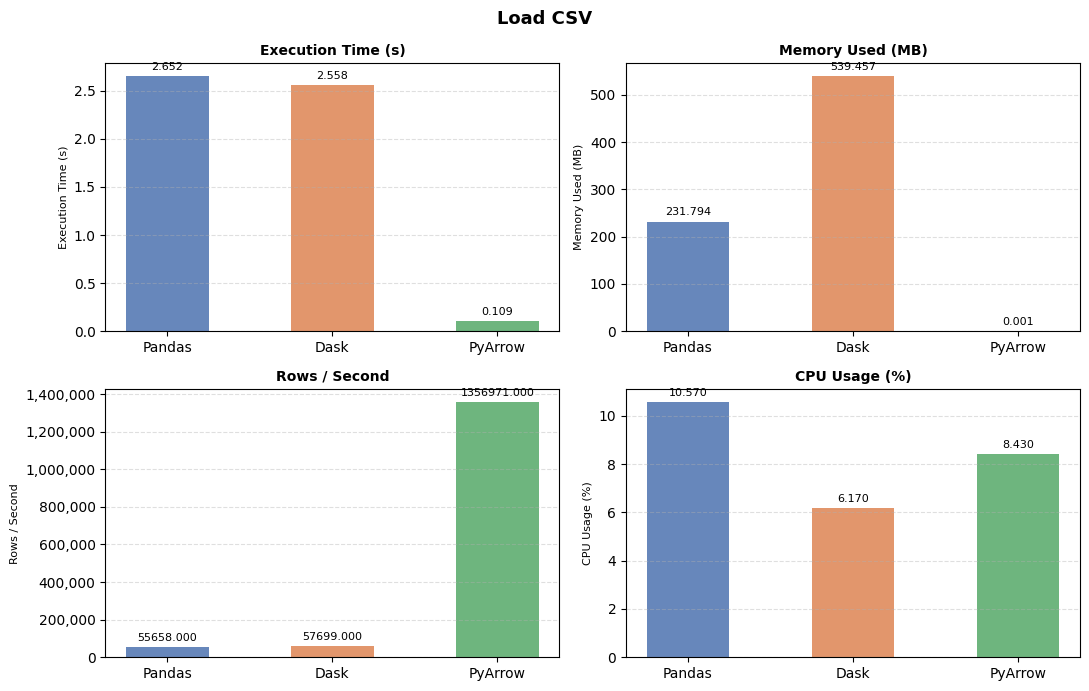

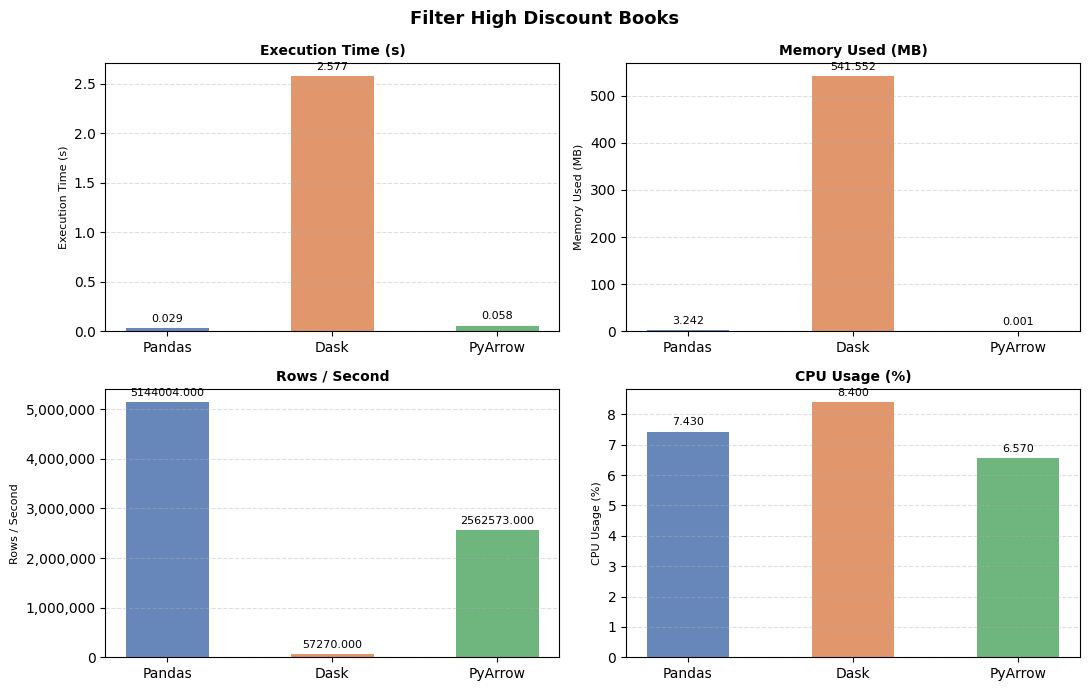

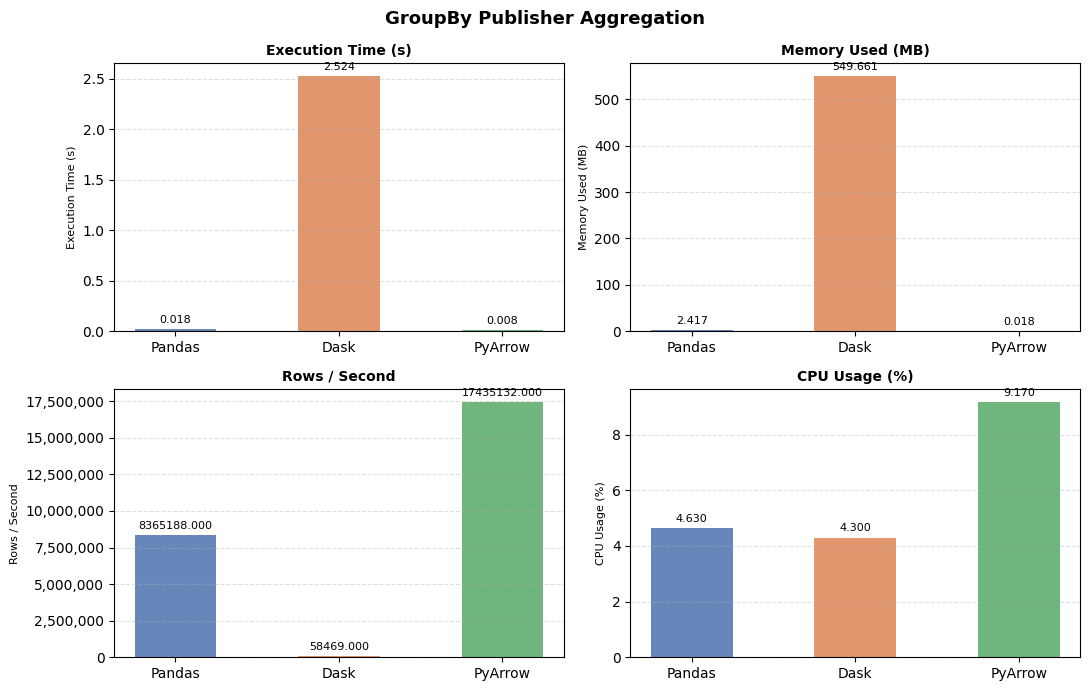

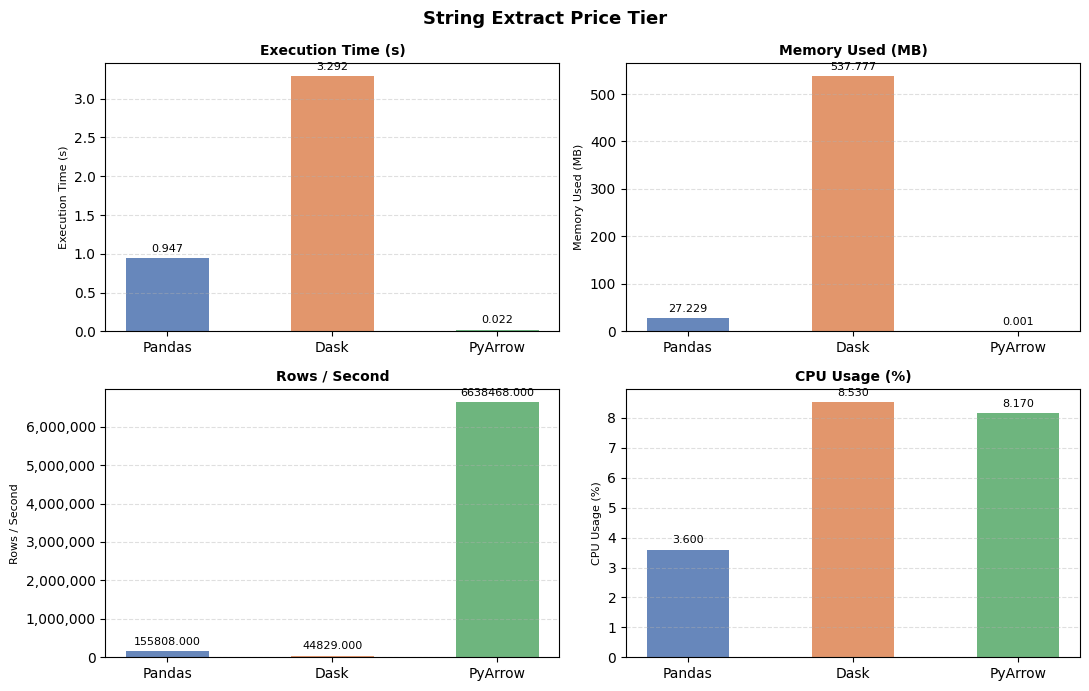

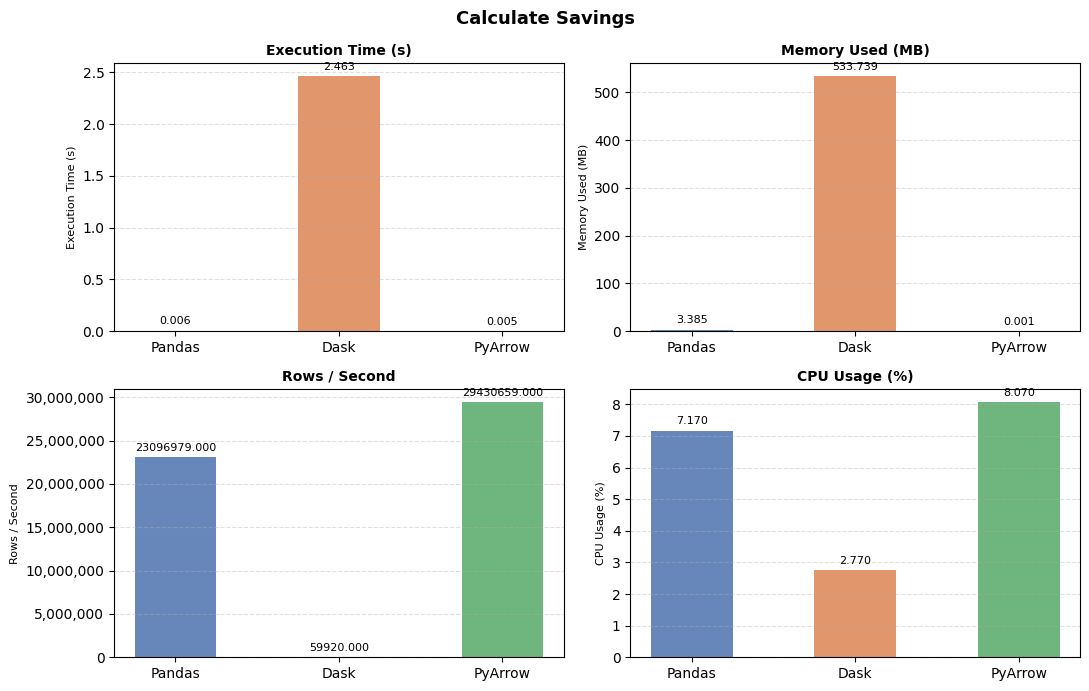

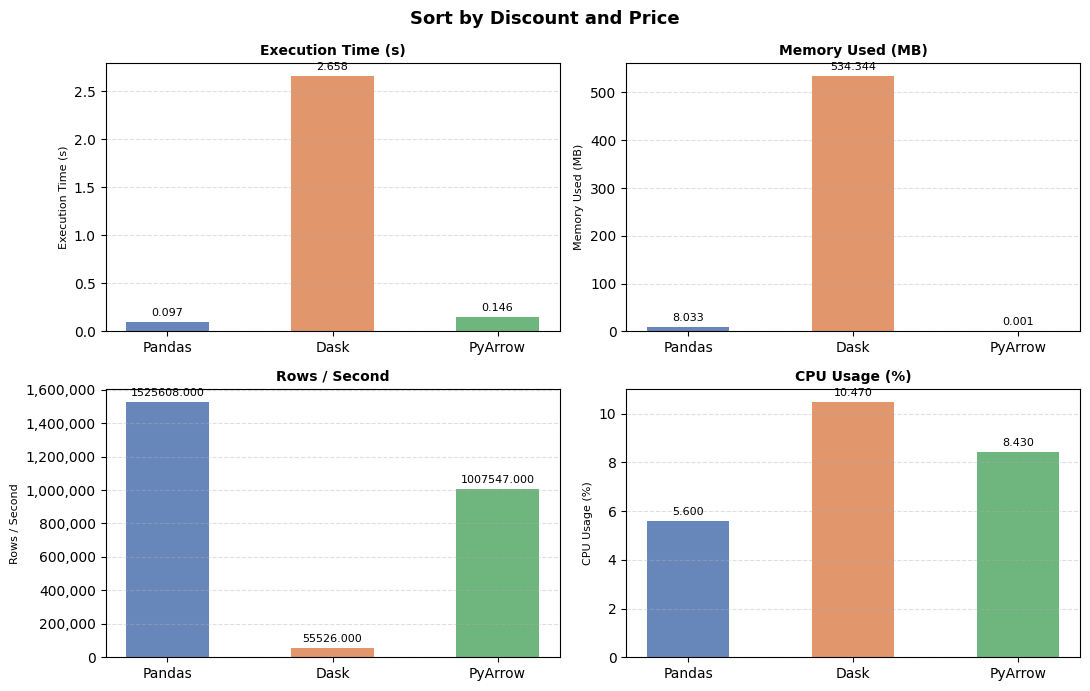

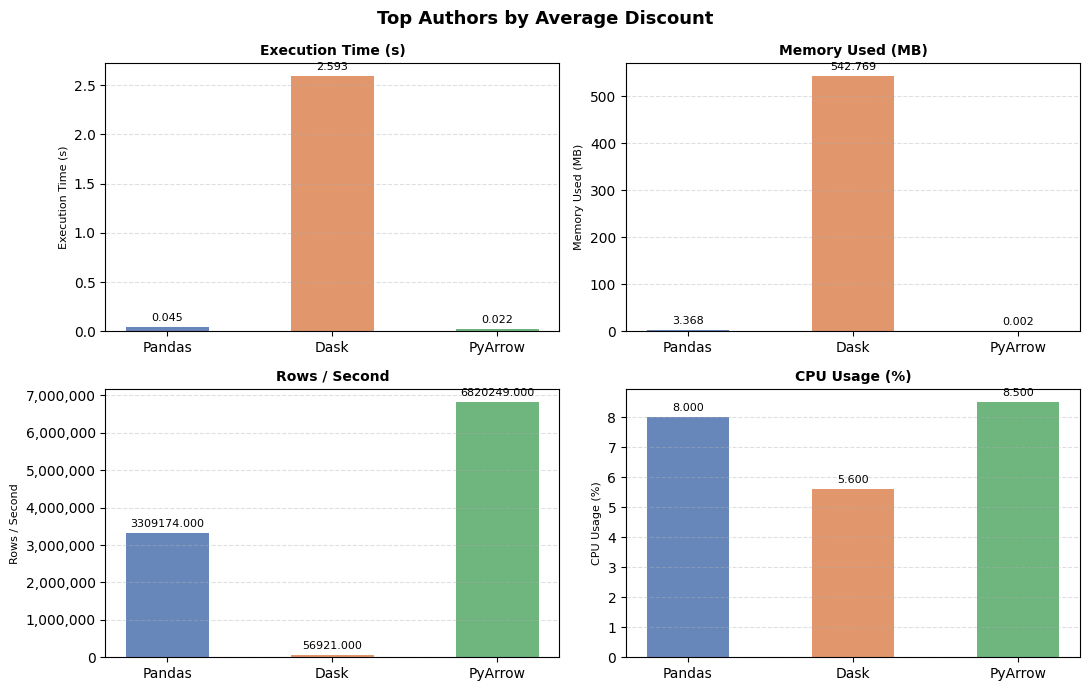

In [10]:
LIBRARIES = ["Pandas", "Dask", "PyArrow"]
COLORS    = ["#4C72B0", "#DD8452", "#55A868"]
METRICS   = [
    ("execution_time_sec",      "Execution Time (s)"),
    ("memory_used_mb",          "Memory Used (MB)"),
    ("throughput_rows_per_sec", "Rows / Second"),
    ("cpu_final_percent",       "CPU Usage (%)"),
]

avg_df = results_df[results_df["run"] == "average"].copy()

for op in avg_df["operation"].unique():
    op_data = avg_df[avg_df["operation"] == op]

    fig, axes = plt.subplots(2, 2, figsize=(11, 7))
    fig.suptitle(op, fontsize=13, fontweight="bold")

    for ax, (metric, ylabel) in zip(axes.flat, METRICS):
        vals = [
            op_data.loc[op_data["library"] == lib, metric].values[0]
            if lib in op_data["library"].values else 0
            for lib in LIBRARIES
        ]
        bars = ax.bar(LIBRARIES, vals, color=COLORS, alpha=0.85, width=0.5)
        ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=8)
        ax.set_title(ylabel, fontsize=10, fontweight="bold")
        ax.set_ylabel(ylabel, fontsize=8)
        ax.grid(axis="y", linestyle="--", alpha=0.4)
        if metric == "throughput_rows_per_sec":
            ax.yaxis.set_major_formatter(
                mticker.FuncFormatter(lambda v, _: f"{v:,.0f}")
            )

    plt.tight_layout()
    plt.show()